In [1]:
import pandas as pd

# Load data
df = pd.read_csv("mexico-real-estate-1.csv")

# Clean price column
df["price_usd"] = df["price_usd"].replace(r'[\$,]', '', regex=True).astype(float)

# Drop missing values
df_clean = df.dropna()

df_clean.head()

,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150,67965.56
1,house,Nuevo León,25.688436,-100.198807,186,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150,94308.80
5,house,Yucatán,21.052583,-89.538639,205,105191.37


In [2]:
df_clean["property_type"].value_counts()

property_type
house        445
apartment    138
Name: count, dtype: int64

In [3]:
features = ["state", "lat", "lon", "area_m2", "price_usd"]
target = "property_type"

X = df_clean[features]
y = df_clean[target]

X.head()

,state,lat,lon,area_m2,price_usd
0,Estado de México,19.560181,-99.233528,150,67965.56
1,Nuevo León,25.688436,-100.198807,186,63223.78
2,Guerrero,16.767704,-99.764383,82,84298.37
3,Guerrero,16.829782,-99.911012,150,94308.80
5,Yucatán,21.052583,-89.538639,205,105191.37


In [4]:
X_encoded = pd.get_dummies(X, columns=["state"])
X_encoded.head()

,lat,lon,area_m2,price_usd,state_Aguascalientes,state_Baja California,state_Baja California Sur,state_Chiapas,state_Chihuahua,state_Distrito Federal,...,state_Quintana Roo,state_San Luis Potosí,state_Sinaloa,state_Sonora,state_Tabasco,state_Tamaulipas,state_Tlaxcala,state_Veracruz de Ignacio de la Llave,state_Yucatán,state_Zacatecas
0,19.560181,-99.233528,150,67965.56,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,25.688436,-100.198807,186,63223.78,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,16.767704,-99.764383,82,84298.37,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,16.829782,-99.911012,150,94308.80,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,21.052583,-89.538639,205,105191.37,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 466
Testing rows: 117


In [6]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

print("Model trained!")

Model trained!


In [7]:
predictions = clf.predict(X_test)
predictions[:10]


array(['house', 'house', 'house', 'house', 'apartment', 'house', 'house',
       'apartment', 'house', 'house'], dtype=object)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2%}")

print(classification_report(y_test, predictions))

Accuracy: 88.89%
              precision    recall  f1-score   support

   apartment       0.85      0.63      0.72        27
       house       0.90      0.97      0.93        90

    accuracy                           0.89       117
   macro avg       0.87      0.80      0.83       117
weighted avg       0.89      0.89      0.88       117



In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
print(cm)

[[17 10]
 [ 3 87]]


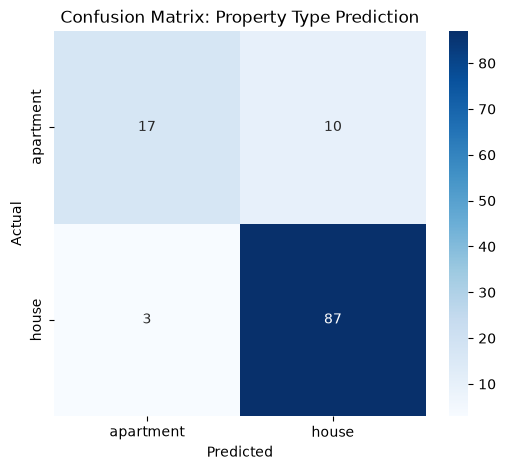

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["apartment", "house"],
            yticklabels=["apartment", "house"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Property Type Prediction")
plt.show()

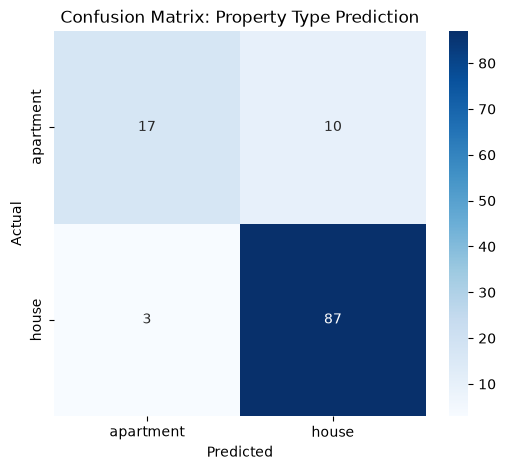

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["apartment", "house"],
            yticklabels=["apartment", "house"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Property Type Prediction")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")  # ← new line
plt.show()